<a href="https://colab.research.google.com/github/shristea7/College-Dump/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def generate_random_state(n):
    return [random.randint(0, n - 1) for _ in range(n)]


In [ ]:
def fitness(state):
    conflicts = 0
    n = len(state)

    for i in range(n):
        for j in range(i + 1, n):
            # Same row
            if state[i] == state[j]:
                conflicts += 1
            # Same diagonal
            elif abs(state[i] - state[j]) == abs(i - j):
                conflicts += 1

    return conflicts


In [ ]:
def generate_neighbors(state):
    neighbors = []
    n = len(state)

    for col in range(n):
        for row in range(n):
            if row != state[col]:
                neighbor = state.copy()
                neighbor[col] = row
                neighbors.append(neighbor)

    return neighbors


In [ ]:
def hill_climbing_with_visualization(n, initial_state):
    current_state = initial_state
    current_fitness = fitness(current_state)
    step = 0

    visualize_board(
        current_state,
        f"Step {step} (Initial State) | Conflicts = {current_fitness}"
    )

    while True:
        neighbors = generate_neighbors(current_state)
        best_state = current_state
        best_fitness = current_fitness

        for neighbor in neighbors:
            f = fitness(neighbor)
            if f < best_fitness:
                best_state = neighbor
                best_fitness = f

        if best_fitness >= current_fitness:
            break

        current_state = best_state
        current_fitness = best_fitness
        step += 1

        visualize_board(
            current_state,
            f"Step {step} | Conflicts = {current_fitness}"
        )

    if current_fitness == 0:
        return current_state
    else:
        return None


In [ ]:
def random_restart_hill_climbing(n, max_restarts=10):
    for restart in range(max_restarts):
        print(f"\n Restart {restart + 1}")

        initial_state = generate_random_state(n)
        solution = hill_climbing_with_visualization(n,initial_state)

        if solution is not None:
            print("Solution Found!")
            return solution

    print("No solution found after all restarts.")
    return None

In [ ]:
def visualize_board(state, title):
    n = len(state)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Draw chessboard squares
    for row in range(n):
        for col in range(n):
            color = "white" if (row + col) % 2 == 0 else "black"
            ax.add_patch(
                plt.Rectangle((col, row), 1, 1, facecolor=color)
            )

    # Place queens at cell centers
    for col in range(n):
        row = state[col]
        ax.text(
            col + 0.5, row + 0.5, "♛",
            ha="center", va="center",
            fontsize=28, color="red"
        )

    # Axis formatting
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks(range(n + 1))
    ax.set_yticks(range(n + 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")

    # Grid lines perfectly aligned
    ax.grid(True)

    # Invert Y-axis so row 0 is at top (chessboard style)
    ax.invert_yaxis()

    ax.set_title(title, fontsize=14)
    plt.show()


In [ ]:
def print_board(state):
    if state is None:
        return

    n = len(state)
    for row in range(n):
        for col in range(n):
            if state[col] == row:
                print("Q", end=" ")
            else:
                print(".", end=" ")
        print()


Enter the value of N (number of queens): 4

 Restart 1


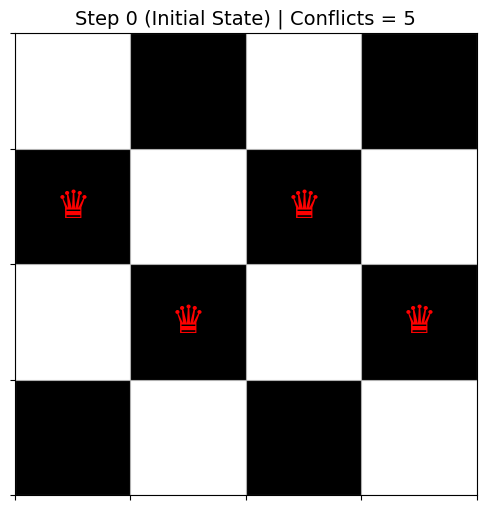

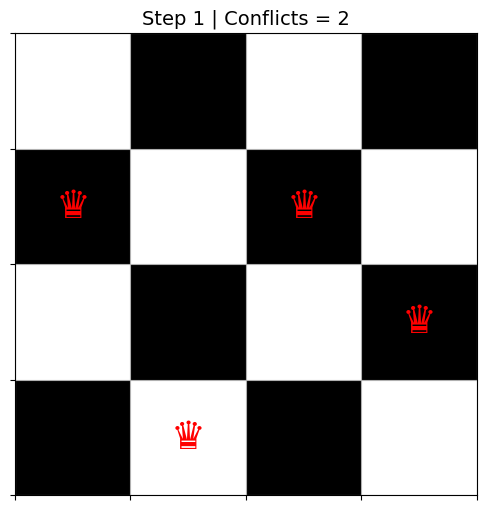

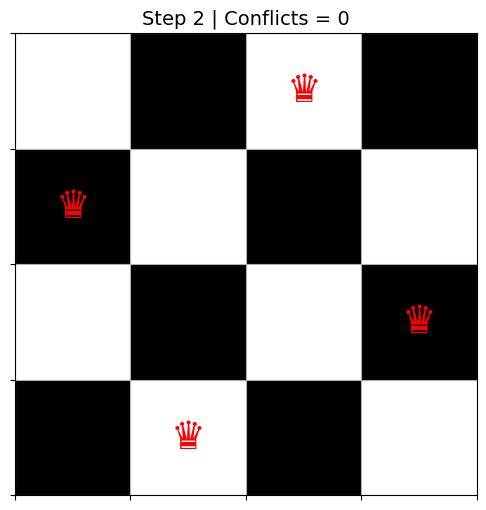

Solution Found!


In [ ]:
if __name__ == "__main__":
    while True:
        try:
            n = int(input("Enter the value of N (number of queens): "))
            if n < 4:
                print("N must be ≥ 4")
            else:
                break
        except ValueError:
            print("Please enter a valid number.")

    random_restart_hill_climbing(n)